<a href="https://colab.research.google.com/github/eftekhar-hossain/Disaster_IEEE-Access/blob/main/damage_identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#%%time
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

import seaborn as sns
import re,nltk,json
from bs4 import BeautifulSoup
### ML Librarires--------------------
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
from sklearn.metrics import average_precision_score,roc_auc_score, roc_curve, precision_recall_curve
###-------------------------------------------
from tensorflow.keras.utils import plot_model
np.random.seed(42)
import string, spacy,unicodedata, random
class color: # Text style
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'
import warnings
warnings.filterwarnings('ignore')
### Pretrained Word Embeddings
main_path = "/kaggle/input/datasets/avijitsaha929/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/"
models_path = "/kaggle/working/datasets/avijitsaha929/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/"
results_path = "/kaggle/working/datasets/avijitsaha929/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Results/"
memes_path = "/kaggle/input/datasets/avijitsaha929/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/"

import os

os.makedirs(models_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True)

2026-03-11 18:25:54.642474: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773253554.665096    1816 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773253554.671712    1816 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773253554.690359    1816 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773253554.690384    1816 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773253554.690387    1816 computation_placer.cc:177] computation placer alr

In [2]:
!pip install keras_preprocessing==1.1.2

In [3]:
from keras.preprocessing import image
from tensorflow.keras.applications.xception import Xception
from keras.applications.vgg16 import VGG16
from keras.applications.vgg19 import VGG19
from keras.applications.densenet import DenseNet121
from keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2
from keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.layers import Dense, GlobalAveragePooling2D, Embedding, LSTM, multiply, concatenate
from keras.models import Model
from keras import preprocessing, Input
from tensorflow import keras
from keras.models import Sequential
#Import from keras_preprocessing not from keras.preprocessing
from keras_preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D
from keras import regularizers, optimizers
from tensorflow.keras.models import load_model
import itertools
from PIL import Image, ImageFile
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Concatenate, Dense, Input, LSTM, Embedding, Dropout, Activation, GRU, Flatten,Reshape,dot,multiply
from tensorflow.keras.layers import Bidirectional, GlobalMaxPool1D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Convolution1D,MaxPooling1D,Conv1D
from tensorflow.keras import initializers, regularizers, constraints, optimizers, layers
from tensorflow.keras.layers import Add, BatchNormalization, Activation, Dropout
from tensorflow.keras.optimizers import RMSprop,Adam,SGD,Nadam
keras.backend.clear_session()

In [4]:
# remove nrows to fetch all data
train_data = []
train_data = pd.read_excel(main_path +'train.xlsx')
valid_data = pd.read_excel(main_path +'valid.xlsx')
test_data = pd.read_excel(main_path +'test.xlsx')

In [5]:
print("Number of Training Data: ",len(train_data))
print("Number of Validation Data: ",len(valid_data))
print("Number of Test Data: ",len(test_data))

Number of Training Data:  2700
Number of Validation Data:  900
Number of Test Data:  900


In [6]:
train_data['Label'].value_counts()

Label
fake    1350
real    1350
Name: count, dtype: int64

In [7]:
valid_data['Label'].value_counts()

Label
fake    450
real    450
Name: count, dtype: int64

In [8]:
test_data['Label'].value_counts()

Label
real    480
fake    420
Name: count, dtype: int64

In [9]:
## Replace Names
train_data['enc_label'] = train_data['Label'].replace({'real':1,'fake':0})
valid_data['enc_label'] = valid_data['Label'].replace({'real':1,'fake':0})
test_data['enc_label'] = test_data['Label'].replace({'real':1,'fake':0})

Display Some Data

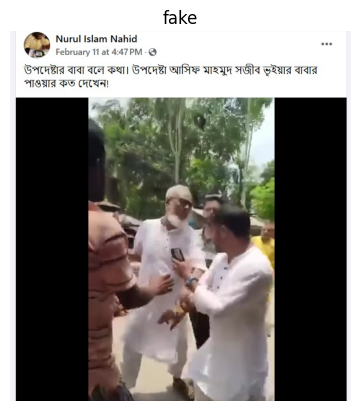

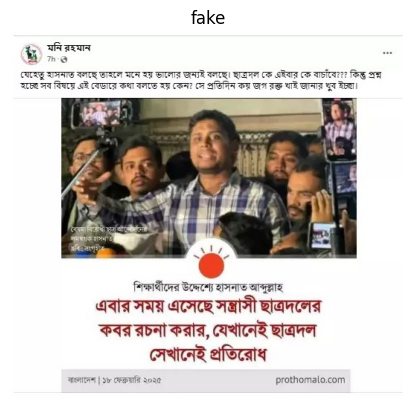

In [10]:
from matplotlib import image as im
for i in range(2):
  data = im.imread(memes_path+'4500 News/'+ train_data['image_name'][i],0)
  plt.figure()
  plt.axis('off')
  plt.imshow(data)
  plt.title(train_data['Label'][i])

'fake'

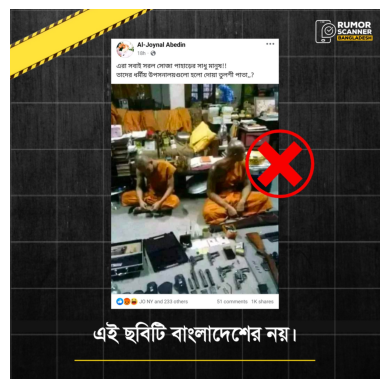

In [11]:
n = 387
from matplotlib import image as im
data = im.imread(memes_path+'4500 News/'+ test_data['image_name'][n],0)
plt.figure()
plt.axis('off')
plt.imshow(data)
#plt.title('Human Damage')
plt.savefig(results_path+"200_negative.png",bbox_inches='tight')
test_data['Label'][n]

#Memes Fetching

In [12]:
## collect image names from the folders
def create_img_array(img_dirct):
    all_imgs = []
    for root, j, files in os.walk(img_dirct):
        for file in files:
            file = root + '' + file
            all_imgs.append(file)
    return all_imgs

def create_img_path(DF, Col_name, img_dir):
    img_path = [img_dir + '' + str(name) for name in DF[Col_name]]
    return img_path


In [13]:
from PIL import Image, ImageFile
from keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

# Function that returns image reading from the path
def get_input(path):
    # Loading image from given path
    # and resizing it to 150*150*3 format
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    img = image.load_img(path, target_size=(150,150))
    return(img)

# Takes in image and preprocess it
def process_input(img):
    # Converting image to array
    img_data = image.img_to_array(img)
    # Adding one more dimension to array
    img_data = np.expand_dims(img_data, axis=0)
    #
    img_data = preprocess_input(img_data)
    return(img_data)


In [14]:
img_dir = "/kaggle/input/datasets/avijitsaha929/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/4500 News/"

# Creating train, test and validation image path
train_img_path = create_img_path(train_data,'image_name', img_dir)
valid_img_path = create_img_path(valid_data,'image_name', img_dir)
test_img_path = create_img_path(test_data,'image_name', img_dir)

In [15]:
# Create an array of training images
errored_data = []
train_images = []
cnt = 1
for i in train_img_path:
  try:
    input_img = get_input(i)
    input_img = process_input(input_img)
    train_images.append(input_img[0])
    cnt = cnt + 1
  except Exception as e:
    print(e)
    errored_data.append(i)

# convert into numpy array
train_image = np.array(train_images)
print(train_image.shape)
print("Number of error: ", len(errored_data))
for ed in errored_data:
  print(ed)

(2700, 150, 150, 3)
Number of error:  0


In [16]:
import pickle as pkl
with open(results_path+'train_image.pkl','wb') as f:
    pkl.dump(train_image, f)

In [17]:
# Create an array of test images
errored_data = []
valid_images = []
for i in valid_img_path:
  try:
    input_img = get_input(i)
    input_img = process_input(input_img)
    valid_images.append(input_img[0])
  except Exception as e:
    errored_data.append(i)

# convert into numpy array
valid_image = np.array(valid_images)
print(valid_image.shape)
print("Errored Data: ", len(errored_data))
for i in errored_data:
  print(i)

(900, 150, 150, 3)
Errored Data:  0


In [18]:
import pickle as pkl
with open(results_path+'valid_image.pkl','wb') as f:
    pkl.dump(valid_image, f)

In [19]:
# Create an array of valid images
errored_data = []
test_images = []
for i in test_img_path:
  try:
    input_img = get_input(i)
    input_img = process_input(input_img)
    test_images.append(input_img[0])
  except Exception as e:
    errored_data.append(i)

# convert into numpy array
test_image = np.array(test_images)
print(test_image.shape)
print("Errored Data: ", len(errored_data))
for i in errored_data:
  print(i)

(900, 150, 150, 3)
Errored Data:  0


In [20]:
import pickle as pkl
with open(results_path+'test_image.pkl','wb') as f:
    pkl.dump(test_image, f)

In [21]:
import pickle as pkl

## Train image
with open(results_path+'train_image.pkl','rb') as f:
  train_image = pkl.load(f)
  print("Training Images:-- ",train_image.shape)

## Valid image
with open(results_path+'valid_image.pkl','rb') as f:
  valid_image = pkl.load(f)
  print("Valid Images:-- ",valid_image.shape)

## Test image
with open(results_path+'test_image.pkl','rb') as f:
  test_image = pkl.load(f)
  print("Test Images:-- ",test_image.shape)

Training Images:--  (2700, 150, 150, 3)
Valid Images:--  (900, 150, 150, 3)
Test Images:--  (900, 150, 150, 3)


In [22]:
# Run this cell after running the next 6 cells
import os

os.makedirs(models_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True)

#Captions Cleaning

In [23]:
stp_path = '/kaggle/input/datasets/avijitsaha929/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Document Categorization/'
stp = open('/kaggle/input/datasets/avijitsaha929/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Document Categorization/bangla_stopwords.txt','r',encoding='utf-8').read().split()

In [24]:
'''
Text Cleaning
'''
def text_cleaning(row):
   if pd.isna(row):
      return ""
   #to remove HTML tags
   text = BeautifulSoup(row, 'html.parser').get_text()
   d = re.sub(r'(https|http)?:\/\/(\w|\.|\/|\?|\=|\&|\%)*\b', '', text, flags=re.MULTILINE) #This line is for removing url
   post = d.replace('\n', '')
   post = post.replace('—', ' ')
   post = post.replace('।', ' ')
   text = ''.join([c for c in post if c not in string.punctuation])
   # to remove special characters
   pattern = r'^\s*|\s\s*'
   text = re.sub(pattern, ' ', text).strip()
   # convert into lower case
   text = text.lower()
   # Stopword
   #result = text.split()
   #text = [word.strip() for word in result if word not in stp ]
   #text =" ".join(text)

   return text

In [25]:
#Removing punctuations
train_data['cleaned'] = train_data['Captions'].apply(text_cleaning)
valid_data['cleaned'] = valid_data['Captions'].apply(text_cleaning)
test_data['cleaned'] = test_data['Captions'].apply(text_cleaning)


## Data samples after cleaning
print("Data samples after cleaning:\n")
for i in range(50):
  print("Original Data:===\n",train_data.Captions[i],"\nCleaned Data:===\n",train_data.cleaned[i], "\nLabel:== ",train_data.Label[i])

Data samples after cleaning:

Original Data:===
 উপদেষ্টার বাবা বলে কথা। উপদেষ্টা আসিফ মাহমুদ সজীব ভৃইয়ার বাবার পাওয়ার কত দেখেন! 
Cleaned Data:===
 উপদেষ্টার বাবা বলে কথা উপদেষ্টা আসিফ মাহমুদ সজীব ভৃইয়ার বাবার পাওয়ার কত দেখেন 
Label:==  fake
Original Data:===
 যেহেতু হাসনাত বলছে তাহলে মনে হয় ভালোর জন্যই বলছে। ছাত্রদল কে এইবার কে বাচাঁবে??? কিন্তু প্রশ্ন হচ্ছে সব বিষয়ে এই বেডারে কথা বলতে হয় কেন? সে প্রতিদিন কয় জগ রক্ত খাই জানার খুব ইচ্ছা। 
Cleaned Data:===
 যেহেতু হাসনাত বলছে তাহলে মনে হয় ভালোর জন্যই বলছে ছাত্রদল কে এইবার কে বাচাঁবে কিন্তু প্রশ্ন হচ্ছে সব বিষয়ে এই বেডারে কথা বলতে হয় কেন সে প্রতিদিন কয় জগ রক্ত খাই জানার খুব ইচ্ছা 
Label:==  fake
Original Data:===
 শোক সংবাদ। খুবই দুঃখের সাথে জানাচ্ছি যে, বীর মুক্তিযোদ্ধা, বিজ্ঞ আইনজীবি স্পষ্ট কথা বলার লোক জেড আই খান পান্না ইন্তেকাল করেছেন, ইন্না-লিল্লাহ ওয়া ইন্না ইলাহি রাজেউন, মহান মুক্তিযুদ্ধের চেতনা সমুন্নত রাখতে, জাতির এই ক্রান্তিলগ্নে তাঁকে খুবই প্রয়োজন ছিল। মহান আল্লাহ যেন তাকে বেহেশতে নসিব করেন। আমিন। 
Cleaned Data:===
 শোক সংব

#One Hot Encoding

In [26]:
encoder = OneHotEncoder(sparse_output=False)
encoded_labels = pd.DataFrame (encoder.fit_transform(train_data[['Label']]))
categories = encoder.categories_[0]
encoded_labels.columns = encoder.get_feature_names_out(['Label'])
train_data= pd.concat([train_data, encoded_labels ], axis=1)

In [27]:
train_data.columns

Index(['image_name', 'Captions', 'Label', 'enc_label', 'cleaned', 'Label_fake',
       'Label_real'],
      dtype='object')

In [28]:
train_data = train_data.rename(columns={'Label_fake':'fake',
                                        'Label_real':'real'
                                       })

In [29]:
train_data.columns

Index(['image_name', 'Captions', 'Label', 'enc_label', 'cleaned', 'fake',
       'real'],
      dtype='object')

In [30]:
train_data

,image_name,Captions,Label,enc_label,cleaned,fake,real
0,1.jpg,উপদেষ্টার বাবা বলে কথা। উপদেষ্টা আসিফ মাহমুদ স...,fake,0,উপদেষ্টার বাবা বলে কথা উপদেষ্টা আসিফ মাহমুদ সজ...,1.0,0.0
1,2.jpg,যেহেতু হাসনাত বলছে তাহলে মনে হয় ভালোর জন্যই বল...,fake,0,যেহেতু হাসনাত বলছে তাহলে মনে হয় ভালোর জন্যই বল...,1.0,0.0
2,3.jpg,"শোক সংবাদ। খুবই দুঃখের সাথে জানাচ্ছি যে, বীর ম...",fake,0,শোক সংবাদ খুবই দুঃখের সাথে জানাচ্ছি যে বীর মুক...,1.0,0.0
3,4.jpg,"হাসিনার স্বীকারোক্তি—কীভাবে আয়নাঘর তৈরি হলো, ক...",fake,0,হাসিনার স্বীকারোক্তি কীভাবে আয়নাঘর তৈরি হলো কী...,1.0,0.0
4,5.jpg,বিশ্ব মানবতা আজ চরম বিপর্যয়ে! আওয়ামী লীগ করার ...,fake,0,বিশ্ব মানবতা আজ চরম বিপর্যয়ে আওয়ামী লীগ করার অ...,1.0,0.0
...,...,...,...,...,...,...,...
2695,2696.jpg,গণোবিবাহের পাত্রী হিসেবে মোট ১১ জন হিন্দু মেয়ে...,fake,0,গণোবিবাহের পাত্রী হিসেবে মোট ১১ জন হিন্দু মেয়ে...,1.0,0.0
2696,2697.jpg,ইজরায়েল তার আত্মরক্ষার অধিকার রাখে,fake,0,ইজরায়েল তার আত্মরক্ষার অধিকার রাখে,1.0,0.0
2697,2698.jpg,জামায়াতে ইসলামীর অমুসলিম শাখায় নাম না লেখালে আ...,fake,0,জামায়াতে ইসলামীর অমুসলিম শাখায় নাম না লেখালে আ...,1.0,0.0
2698,2699.jpg,দেশে যাই হোক বিয়ে করতেই হবে,fake,0,দেশে যাই হোক বিয়ে করতেই হবে,1.0,0.0


#Dataset Statistics

In [31]:
## Individual tweets length calculation
def char_length(row):
    return len(row.split())


labels = ['fake','real']
# Count number of unique words in each set
def dataset_statistics(dataset):
  for l in labels:
    word_list = [word.strip() for t in list(dataset[dataset[l]==1].cleaned) for word in t.strip().split()]
    counts = dict()
    for word in word_list:
        counts[word] = counts.get(word, 0)+1
      # sort the dictionary of word list
    ordered = sorted(counts.items(), key= lambda item: item[1],reverse = True)
    print(f"\nClass Name:--> {l} ")
    print("Number of Words:{}".format(len(word_list)))
    print("Number of Unique Words:{}".format(len(np.unique(word_list))))
    print("Maximum Caption length: {}".format(max(dataset[dataset[l]==1].cleaned.apply(char_length))))
    print("Minimum Caption length: {}".format(min(dataset[dataset[l]==1].cleaned.apply(char_length))))
    print("Average Words in texts: {}".format(np.mean(dataset[dataset[l]==1].cleaned.apply(char_length))))
    print(color.BOLD+"\nMost Frequent Words:\n"+color.END)
    for k,v in ordered[:10]:
      print("{}\t{}".format(k,v))


In [32]:
dataset_statistics(train_data)


Class Name:--> fake 
Number of Words:15216
Number of Unique Words:6300
Maximum Caption length: 87
Minimum Caption length: 1
Average Words in texts: 11.27111111111111

Most Frequent Words:

থেকে	123
করে	106
জন্য	100
না	78
ও	76
এই	70
ছবি	59
নিয়ে	50
টাকা	50
করতে	49

Class Name:--> real 
Number of Words:11531
Number of Unique Words:4824
Maximum Caption length: 20
Minimum Caption length: 3
Average Words in texts: 8.541481481481481

Most Frequent Words:

ও	111
নিয়ে	71
থেকে	68
না	61
করতে	52
উপদেষ্টা	50
প্রধান	44
হবে	43
কেন	43
গ্রেপ্তার	40


In [33]:
### Plot a Distribution
def sentence_length_per_class(dataset,set_name):
  label = dataset[['fake','real']]
  label = label.values
  comment = dataset['cleaned']
  comment = comment.values
  y = np.zeros(label.shape)
  for ix in range(comment.shape[0]):
      l = len(comment[ix].split())
      if label[ix][0] :
          y[ix][0] = l
      if label[ix][1] :
          y[ix][1] = l

  labelsplt = ['fake','real' ]
  color = ['red','green']
  bins = [1,5,10,15,20,25,30,35,40,45,50,55,60]
  plt.figure(figsize=(5,3))
  #plt.title ('Tweets Length Distribution Per Class')
  plt.hist(y,bins = bins,label = labelsplt,color = color)
  plt.axis([0, 40, 0, 800])
  plt.xlabel('Length of the Caption')
  plt.ylabel('Number of Captions ')
  plt.legend()
  #plt.savefig(results_path+'length-dist.png',dpi = 600,bbox_inches ='tight')
  #plt.grid(True)
  plt.show()


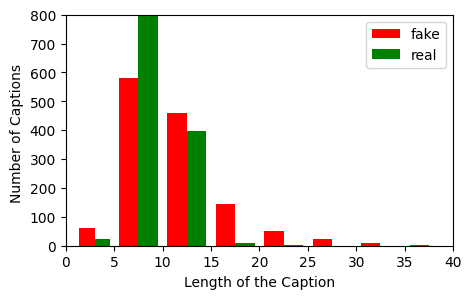

In [34]:
sentence_length_per_class(train_data,'Training')

##Jacard Similarity

In [35]:
## Individual tweets length calculation
def char_length(row):
    return len(row.split())

lables = ['fake','real']
# Count number of unique words in each set

final_list = []

for l in lables:
  label_wise_word_list = []
  word_list = [word.strip() for t in list(train_data[train_data[l]==1].cleaned) for word in t.strip().split()]
  counts = dict()
  for word in word_list:
      counts[word] = counts.get(word,0) + 1
      # sort the dictionary of word list
  ordered = sorted(counts.items(), key= lambda item: item[1], reverse = True)
  print(f"\nClass Name:--> {l} ")

  for k,v in ordered[:400]:
    label_wise_word_list.append(k)

  final_list.append(label_wise_word_list)


Class Name:--> fake 

Class Name:--> real 


In [36]:
def jaccard_similarity(list1, list2):
    s1 = set(list1)
    s2 = set(list2)
    return float(len(s1.intersection(s2)) / len(s1.union(s2)))

In [37]:
jaccard_similarity(final_list[0],final_list[1])

0.26582278481012656

##Evaluation Metrics

In [38]:
'''Evaluation Parameters'''

def print_metrices(true,pred):
    print(confusion_matrix(true,pred))
    print(classification_report(true,pred,target_names=['Fake','Real']))
    print("Accuracy : ",accuracy_score(true,pred))
    print("Precison : ",precision_score(true,pred, average = 'weighted'))
    print("Recall : ",recall_score(true,pred,  average = 'weighted'))
    print("F1 : ",f1_score(true,pred,  average = 'weighted'))

#Callbacks

In [39]:
''' Callbacks'''
import tensorflow.keras as keras
keras.backend.clear_session()
def callbacks_with_garbage(model_name):
  accuracy_threshold = 0.98

  class myCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')>accuracy_threshold):
          print("\nReached %2.2f%% accuracy so we will stop trianing" % (accuracy_threshold*100))
          self.model.stop_training = True

  # Garbage Collector - use it like gc.collect()
  import gc
  # Custom Callback To Include in Callbacks List At Training Time
  class GarbageCollectorCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()


  acc_callback = myCallback()
  gc_callback = GarbageCollectorCallback()
  # Saved the Best Model
  filepath = models_path+f"{model_name}.h5"
  checkpoint = keras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=False, mode='max')
  # callback list
  callback_list = [acc_callback, gc_callback, checkpoint]

  return callback_list

In [40]:
''' Callbacks'''
keras.backend.clear_session()
def callbacks_check(model_name):
  accuracy_threshold = 0.98

  class myCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')>accuracy_threshold):
          print("\nReached %2.2f%% accuracy so we will stop trianing" % (accuracy_threshold*100))
          self.model.stop_training = True

  acc_callback = myCallback()
  # Saved the Best Model
  filepath = models_path+f"{model_name}.h5"
  checkpoint = keras.callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=2, save_best_only=True,
                                             save_weights_only=False, mode='max')
  # callback list
  callback_list = [acc_callback, checkpoint]

  return callback_list

In [41]:
from sklearn.utils import compute_class_weight
class_weights = compute_class_weight(
                                        class_weight = "balanced",
                                        classes = np.unique(train_data['enc_label']),
                                        y = train_data['enc_label']
                                    )
weight = {i : class_weights[i] for i in range(2)}
weight

{0: np.float64(1.0), 1: np.float64(1.0)}

Imports (Clean Version)

In [42]:
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.utils import to_categorical

Tokenizer

In [43]:
def text_tokenizer(train, valid, test, vocab_size=50000, max_len=180):

    tokenizer = Tokenizer(num_words=vocab_size, oov_token="<oov>")
    tokenizer.fit_on_texts(train['cleaned'])

    train_seq = tokenizer.texts_to_sequences(train['cleaned'])
    valid_seq = tokenizer.texts_to_sequences(valid['cleaned'])
    test_seq = tokenizer.texts_to_sequences(test['cleaned'])

    train_pad = pad_sequences(train_seq, maxlen=max_len, padding='post')
    valid_pad = pad_sequences(valid_seq, maxlen=max_len, padding='post')
    test_pad = pad_sequences(test_seq, maxlen=max_len, padding='post')

    vocab_size = len(tokenizer.word_index)+1

    return train_pad, valid_pad, test_pad, vocab_size

In [44]:
train_pad_sequences, valid_pad_sequences, test_pad_sequences, vocab_size = text_tokenizer(
    train_data, valid_data, test_data
)

Labels

In [45]:
y_train = to_categorical(train_data['enc_label'])
y_valid = to_categorical(valid_data['enc_label'])
y_test  = to_categorical(test_data['enc_label'])

In [46]:
print(y_train.shape)
print(y_train[:5])

(2700, 2)
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


Text Models

In [47]:
def build_text_model(model_type, max_len, vocab_size):

    inputs = Input(shape=(max_len,))
    x = Embedding(vocab_size, 128)(inputs)

    if model_type == "LSTM":
        x = LSTM(64)(x)

    elif model_type == "GRU":
        x = GRU(64)(x)

    elif model_type == "CNN":
        x = Conv1D(128,3,activation='relu')(x)
        x = MaxPooling1D(2)(x)
        x = Flatten()(x)

    elif model_type == "BiLSTM":
        x = Bidirectional(LSTM(64))(x)

    outputs = Dense(2, activation='softmax')(x)

    return Model(inputs, outputs)

Visual Model (Xception)

In [48]:
def build_visual_model():

    base = tf.keras.applications.Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150,150,3)
    )

    for layer in base.layers[:-20]:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base.output)

    outputs = Dense(2, activation='softmax')(x)

    return Model(base.input, outputs)

Multimodal Model

In [49]:
def build_multimodal_model(text_model, visual_model):

    combined = concatenate([text_model.output, visual_model.output])

    x = Dropout(0.3)(combined)

    x = Dense(64, activation='relu')(x)

    outputs = Dense(2, activation='softmax')(x)

    model = Model(
        inputs=[visual_model.input, text_model.input],
        outputs=outputs
    )

    model.compile(
        optimizer=Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

Training Loop

In [50]:
text_models = ["LSTM","CNN","GRU","BiLSTM"]

results = {}

for tm in text_models:

    print("Training Model: Xception +", tm)

    text_model = build_text_model(tm, 180, vocab_size)

    visual_model = build_visual_model()

    model = build_multimodal_model(text_model, visual_model)

    model_name = "Xception"+tm

    checkpoint = ModelCheckpoint(
        models_path+"Models_3/"+model_name+".h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    model.fit(
        [train_image, train_pad_sequences],
        y_train,
        validation_data=([valid_image,valid_pad_sequences],y_valid),
        epochs=10,
        batch_size=32,
        class_weight=weight,
        callbacks=[checkpoint]
    )

Training Model: Xception + LSTM


I0000 00:00:1773253677.935360    1816 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773253677.940662    1816 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/10


I0000 00:00:1773253690.218674    1886 cuda_dnn.cc:529] Loaded cuDNN version 91002


85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.5059 - loss: 0.6534
Epoch 1: val_accuracy improved from -inf to 0.73667, saving model to /kaggle/working/datasets/avijitsaha929/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/Models_3/XceptionLSTM.h5


...

85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step - accuracy: 0.7535 - loss: 0.5861 - val_accuracy: 0.9044 - val_loss: 0.5465
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.8597 - loss: 0.5269
Epoch 3: val_accuracy improved from 0.90444 to 0.96333, saving model to /kaggle/working/datasets/avijitsaha929/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/Models_3/XceptionBiLSTM.h5


85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 0.8596 - loss: 0.5268 - val_accuracy: 0.9633 - val_loss: 0.4715
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8473 - loss: 0.4882
Epoch 4: val_accuracy improved from 0.96333 to 0.98778, saving model to /kaggle/working/datasets/avijitsaha929/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/Models_3/XceptionBiLSTM.h5


85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step - accuracy: 0.8473 - loss: 0.4881 - val_accuracy: 0.9878 - val_loss: 0.4109
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.8717 - loss: 0.4449
Epoch 5: val_accuracy improved from 0.98778 to 0.99556, saving model to /kaggle/working/datasets/avijitsaha929/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/Models_3/XceptionBiLSTM.h5


85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - accuracy: 0.8718 - loss: 0.4448 - val_accuracy: 0.9956 - val_loss: 0.3689
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8688 - loss: 0.4111
Epoch 6: val_accuracy did not improve from 0.99556
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 142ms/step - accuracy: 0.8688 - loss: 0.4111 - val_accuracy: 0.6856 - val_loss: 0.6125
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8835 - loss: 0.3736
Epoch 7: val_accuracy did not improve from 0.99556
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 142ms/step - accuracy: 0.8835 - loss: 0.3736 - val_accuracy: 0.9933 - val_loss: 0.2986
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.8973 - loss: 0.3446
Epoch 8: val_accuracy did not improve from 0.99556
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 143ms/step - accuracy: 0.8973 - loss: 0.3446 - val_accuracy: 0.9556 - val_loss: 0.3172
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9092 - loss: 0.3227
Epoch 9: val_accuracy improved 

85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 151ms/step - accuracy: 0.9093 - loss: 0.3225 - val_accuracy: 0.9978 - val_loss: 0.2194
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9218 - loss: 0.2763
Epoch 10: val_accuracy did not improve from 0.99778
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - accuracy: 0.9218 - loss: 0.2761 - val_accuracy: 0.9978 - val_loss: 0.1954


Evaluation

In [51]:
def evaluate_model(model_name):

    model = tf.keras.models.load_model(
        models_path+"Models_3/"+model_name+".h5"
    )

    preds = model.predict([test_image,test_pad_sequences])

    y_pred = np.argmax(preds,axis=1)

    y_true = test_data['enc_label']

    return {
        "Accuracy":accuracy_score(y_true,y_pred)*100,
        "Precision":precision_score(y_true,y_pred)*100,
        "Recall":recall_score(y_true,y_pred)*100,
        "F1":f1_score(y_true,y_pred)*100
    }

Save Results

In [52]:
results = {}

for tm in text_models:

    name = "Xception"+tm

    results[name] = evaluate_model(name)

os.makedirs(models_path+"Results_3",exist_ok=True)

with open(models_path+"Results_3/multimodal_results.json","w") as f:

    json.dump(results,f)

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step


29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 214ms/step


29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step


29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step


Performance Table

In [53]:
df = pd.DataFrame(results).T

df

,Accuracy,Precision,Recall,F1
XceptionLSTM,99.222222,98.762887,99.791667,99.274611
XceptionCNN,99.333333,98.765432,100.000000,99.378882
XceptionGRU,98.888889,97.959184,100.000000,98.969072
XceptionBiLSTM,98.777778,97.955010,99.791667,98.864809


Confusion Matrix for All Models

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


def plot_confusion_matrix(model_name):

    model = tf.keras.models.load_model(
        models_path + "Models_3/" + model_name + ".h5"
    )

    preds = model.predict([test_image, test_pad_sequences])
    y_pred = np.argmax(preds, axis=1)

    y_true = test_data['enc_label']

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Fake","Real"],
                yticklabels=["Fake","Real"])

    plt.title("Confusion Matrix: " + model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


plot_confusion_matrix("Xception+LSTM")
plot_confusion_matrix("Xception+CNN")
plot_confusion_matrix("Xception+GRU")
plot_confusion_matrix("Xception+BiLSTM")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/kaggle/working/datasets/avijitsaha929/ndd-news-detection-dataset/NDD_News_Detection_Dataset/Online News/Dataset-4500/Fake News/Models/Models_3/Xception+LSTM.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)